In [3]:
#importacion de librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [4]:
# Cargar fichero
df = pd.read_csv('df_modelo_target.csv')

In [5]:
#cambio de nombres de campos climatologicos
df = df.rename(columns={
    "T": "temperatura_media",
    "TM": "temperatura_maxima",
    "Tm": "temperatura_minima",
    "V": "viento",
    "VM": "viento_maximo",
    "PP": "precipitaciones",
    "H": "humedad"
})

In [6]:
#paso de string a tipo hora
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])
#creacion de un nuevo campo hora con la hora redondeada
df["hora_redondeada"] = (
    df["fecha_hora"] +
    pd.to_timedelta(
        (df["fecha_hora"].dt.minute > 30).astype(int),
        unit="h"
    )
).dt.floor("H")

/tmp/ipykernel_16429/2514605811.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ).dt.floor("H")


In [7]:
df["hora_redondeada"] = df["hora_redondeada"].dt.hour

In [8]:
df

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,viento,viento_maximo,precipitaciones,humedad,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada
0,Burgos,2024-01-01,LUNES,1:52,3,Urbano,C.A.U. Burgos,39,Mujer,1,...,17.0,27.8,1.27,84.0,1,2024,188,188,2024-01-01 01:52:00,2
1,Burgos,2024-01-01,LUNES,17:57,2,Urbano,C.A.U. Burgos,80,Hombre,1,...,17.0,27.8,1.27,84.0,1,2024,188,188,2024-01-01 17:57:00,18
2,Burgos,2024-01-01,LUNES,2:59,2,Urbano,C.A.U. Burgos,58,Mujer,1,...,17.0,27.8,1.27,84.0,1,2024,188,188,2024-01-01 02:59:00,3
3,Burgos,2024-01-01,LUNES,13:28,3,Urbano,C.A.U. Burgos,55,Mujer,1,...,17.0,27.8,1.27,84.0,1,2024,188,188,2024-01-01 13:28:00,13
4,Burgos,2024-01-01,LUNES,10:45,4,Urbano,C.A.U. Burgos,66,Mujer,1,...,17.0,27.8,1.27,84.0,1,2024,188,188,2024-01-01 10:45:00,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790985,Ávila,2025-08-31,DOMINGO,19:26,3,Rural,C.A. Ávila,71,Hombre,31,...,0.0,0.0,0.00,0.0,8,2025,79,79,2025-08-31 19:26:00,19
790986,Ávila,2025-08-31,DOMINGO,16:55,4,Urbano,C.A. Ávila,68,Mujer,31,...,0.0,0.0,0.00,0.0,8,2025,79,79,2025-08-31 16:55:00,17
790987,Ávila,2025-08-31,DOMINGO,23:35,4,Urbano,C.A. Ávila,69,Mujer,31,...,0.0,0.0,0.00,0.0,8,2025,79,79,2025-08-31 23:35:00,0
790988,Ávila,2025-08-31,DOMINGO,17:55,4,Urbano,C.A. Ávila,69,Mujer,31,...,0.0,0.0,0.00,0.0,8,2025,79,79,2025-08-31 17:55:00,18


In [9]:
# Crear grupo de edad
df["grupo_edad"] = df["edad"].apply(
    lambda x:
        "infante" if x <= 12 else
        "adolescente" if x <= 17 else
        "joven" if x <= 28 else
        "adulto" if x <= 50 else
        "anciano-joven" if x <= 65 else "anciano"
)

# crear grupo temperatura media
df["grupo_temperatura_media"] = df["temperatura_media"].apply(
    lambda x:
        "mucho-frio" if x <= 5 else
        "frio" if x <= 15 else
        "calido" if x <= 20 else
        "calor" if x <= 25 else
        "mucho-calor"
)

# crear grupo precitipationes media
df["grupo_precipitaciones"] = df["precipitaciones"].apply(
    lambda x:
        "sin_lluvia" if x <= 0 else
        "llovizna" if x <= 2 else
        "lluvia-moderada" if x <= 15 else
        "lluvia-fuerte" if x <= 30 else
        "lluvia-muy-fuerte" if x <= 60 else
        "torrencial"
)

In [10]:
df.head()

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,humedad,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada,grupo_edad,grupo_temperatura_media,grupo_precipitaciones
0,Burgos,2024-01-01,LUNES,1:52,3,Urbano,C.A.U. Burgos,39,Mujer,1,...,84.0,1,2024,188,188,2024-01-01 01:52:00,2,adulto,mucho-frio,llovizna
1,Burgos,2024-01-01,LUNES,17:57,2,Urbano,C.A.U. Burgos,80,Hombre,1,...,84.0,1,2024,188,188,2024-01-01 17:57:00,18,anciano,mucho-frio,llovizna
2,Burgos,2024-01-01,LUNES,2:59,2,Urbano,C.A.U. Burgos,58,Mujer,1,...,84.0,1,2024,188,188,2024-01-01 02:59:00,3,anciano-joven,mucho-frio,llovizna
3,Burgos,2024-01-01,LUNES,13:28,3,Urbano,C.A.U. Burgos,55,Mujer,1,...,84.0,1,2024,188,188,2024-01-01 13:28:00,13,anciano-joven,mucho-frio,llovizna
4,Burgos,2024-01-01,LUNES,10:45,4,Urbano,C.A.U. Burgos,66,Mujer,1,...,84.0,1,2024,188,188,2024-01-01 10:45:00,11,anciano,mucho-frio,llovizna


In [11]:
#bloque para cambiar todas los campos por numeros para tener valores numeros tipo 0,1,2 etc
from sklearn.preprocessing import LabelEncoder

#Copia del dataset,
df_encoded = df.copy()

#Convertir automáticamente columnas categóricas,
for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [12]:
df_encoded.head()

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,humedad,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada,grupo_edad,grupo_temperatura_media,grupo_precipitaciones
0,0,0,2,712,2,1,4,39,1,1,...,84.0,1,2024,188,188,2024-01-01 01:52:00,2,1,4,0
1,0,0,2,537,1,1,4,80,0,1,...,84.0,1,2024,188,188,2024-01-01 17:57:00,18,2,4,0
2,0,0,2,1019,1,1,4,58,1,1,...,84.0,1,2024,188,188,2024-01-01 02:59:00,3,3,4,0
3,0,0,2,268,2,1,4,55,1,1,...,84.0,1,2024,188,188,2024-01-01 13:28:00,13,3,4,0
4,0,0,2,105,3,1,4,66,1,1,...,84.0,1,2024,188,188,2024-01-01 10:45:00,11,2,4,0


In [13]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790990 entries, 0 to 790989
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   provincia                790990 non-null  int64         
 1   fecha                    790990 non-null  int64         
 2   dia_semana               790990 non-null  int64         
 3   hora                     790990 non-null  int64         
 4   nivel_triaje             790990 non-null  int64         
 5   ambito_procedencia       790990 non-null  int64         
 6   hospital                 790990 non-null  int64         
 7   edad                     790990 non-null  int64         
 8   sexo                     790990 non-null  int64         
 9   dia                      790990 non-null  int64         
 10  temperatura_media        790990 non-null  float64       
 11  temperatura_maxima       790990 non-null  float64       
 12  temperatura_mini

In [14]:
#cambiar numero a mes, mapeo
meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

df["mes_nombre"] = df["mes"].map(meses)

In [15]:
df.columns

Index(['provincia', 'fecha', 'dia_semana', 'hora', 'nivel_triaje',
       'ambito_procedencia', 'hospital', 'edad', 'sexo', 'dia',
       'temperatura_media', 'temperatura_maxima', 'temperatura_minima',
       'viento', 'viento_maximo', 'precipitaciones', 'humedad', 'mes', 'year',
       'pacientes_ayer', 'target_pacientes', 'fecha_hora', 'hora_redondeada',
       'grupo_edad', 'grupo_temperatura_media', 'grupo_precipitaciones',
       'mes_nombre'],
      dtype='object')

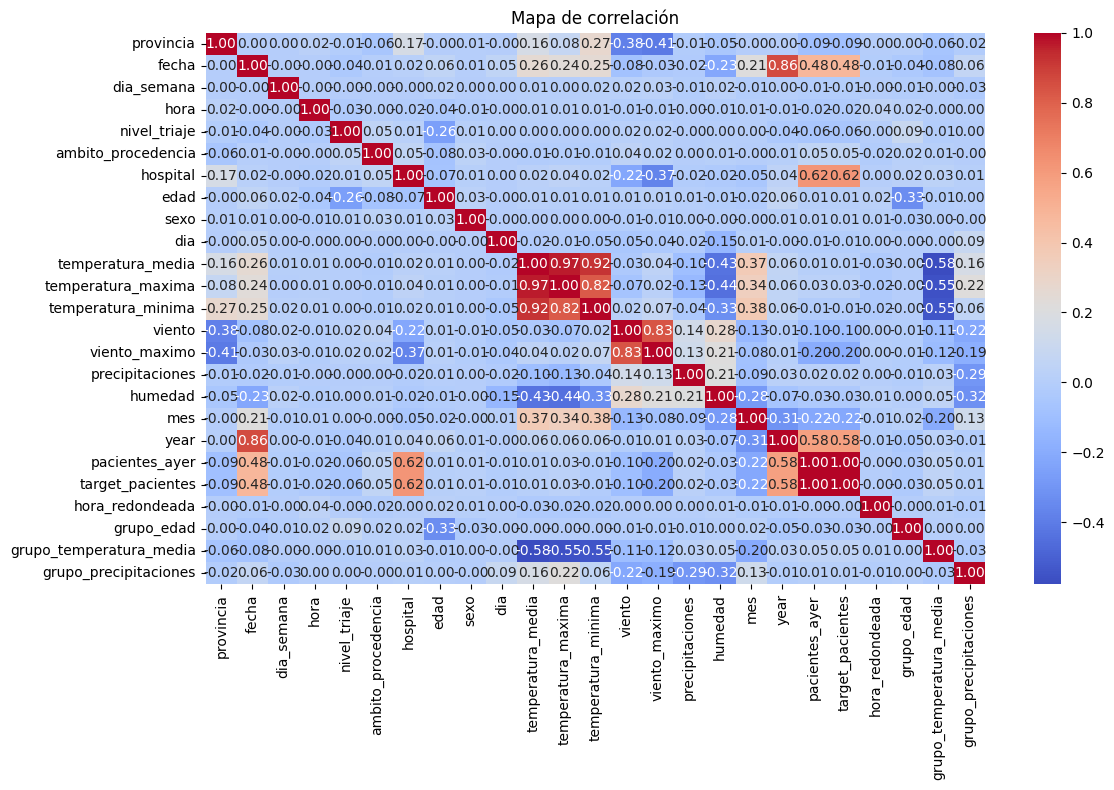

In [16]:
# Seleccionar solo columnas numéricas
numeric_df = df_encoded.select_dtypes(include=["int64", "int32", "float64"])

# Calcular correlación
corr = numeric_df.corr()

# Crear heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

LOS MESES SEPTIERMBRE, NOVIEMBRE, OCTUBRE Y DICIEMBRE NO TIENEN REGISTROS EN ALGUNAS PROVINCIAS ASÍ QUE COMO SE PODRÍA CONSIDERAR QUE SON OUTLIERS VAMOS A QUITARLOS DE ESTA GRÁFICA

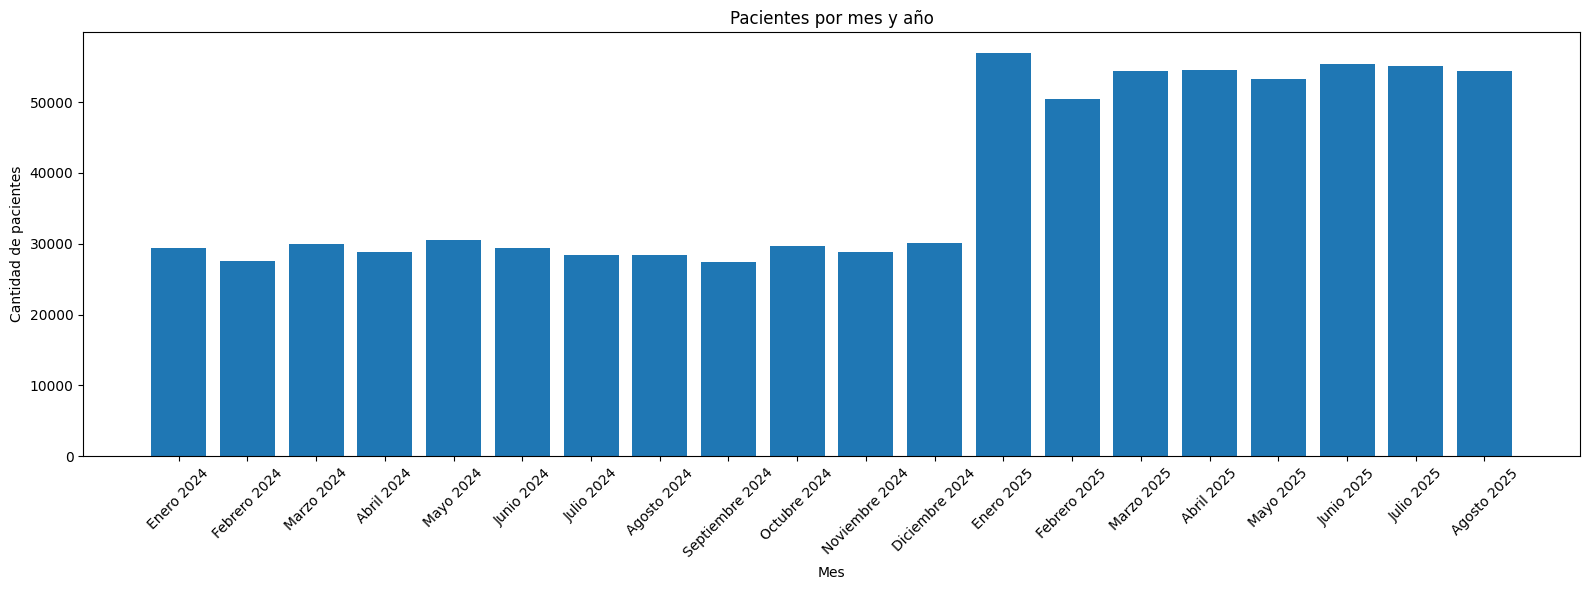

In [17]:
# Eliminar octubre, noviembre y diciembre de 2025
df = df[
    ~(
        (df["year"] == 2025) &
        (df["mes"].isin([9, 10, 11, 12]))
    )
]

# Agrupar
grouped = (
    df.groupby(["year", "mes", "mes_nombre"])
      .size()
      .reset_index(name="pacientes")
)

# Ordenar
grouped = grouped.sort_values(["year", "mes"])

# Etiqueta visual
grouped["periodo"] = (
    grouped["mes_nombre"]
    + " "
    + grouped["year"].astype(str)
)

# Graficar
plt.figure(figsize=(16,6))

plt.bar(grouped["periodo"], grouped["pacientes"])

plt.xticks(rotation=45)
plt.xlabel("Mes")
plt.ylabel("Cantidad de pacientes")
plt.title("Pacientes por mes y año")

plt.tight_layout()
plt.show()
# posible sesgo en los datos ya que a partir de enero de 2025 tenemos el doble de registros

In [18]:
# Comprobamos duplicados para descartar que el aumento de 2025 se deba a ello
df[(df["year"] == 2025) & df.duplicated(keep=False)]

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada,grupo_edad,grupo_temperatura_media,grupo_precipitaciones,mes_nombre
79784,Burgos,2025-01-30,JUEVES,16:00,4,Urbano,C.A.U. Burgos,41,Mujer,30,...,1,2025,392,392,2025-01-30 16:00:00,16,adulto,mucho-frio,lluvia-moderada,Enero
79888,Burgos,2025-01-30,JUEVES,16:00,4,Urbano,C.A.U. Burgos,41,Mujer,30,...,1,2025,392,392,2025-01-30 16:00:00,16,adulto,mucho-frio,lluvia-moderada,Enero
101302,Burgos,2025-03-28,VIERNES,14:09,4,Urbano,C.A.U. Burgos,80,Mujer,28,...,3,2025,369,369,2025-03-28 14:09:00,14,anciano,frio,sin_lluvia,Marzo
101498,Burgos,2025-03-28,VIERNES,14:09,4,Urbano,C.A.U. Burgos,80,Mujer,28,...,3,2025,369,369,2025-03-28 14:09:00,14,anciano,frio,sin_lluvia,Marzo
110597,Burgos,2025-04-22,MARTES,12:17,4,Urbano,C.A.U. Burgos,62,Hombre,22,...,4,2025,417,417,2025-04-22 12:17:00,12,anciano-joven,frio,lluvia-moderada,Abril
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776966,Ávila,2025-04-20,DOMINGO,4:10,3,Urbano,C.A. Ávila,82,Hombre,20,...,4,2025,92,92,2025-04-20 04:10:00,4,anciano,frio,lluvia-moderada,Abril
781131,Ávila,2025-05-29,JUEVES,22:20,Desconocido,Urbano,C.A. Ávila,31,Mujer,29,...,5,2025,115,115,2025-05-29 22:20:00,22,adulto,calido,sin_lluvia,Mayo
781193,Ávila,2025-05-29,JUEVES,22:20,Desconocido,Urbano,C.A. Ávila,31,Mujer,29,...,5,2025,115,115,2025-05-29 22:20:00,22,adulto,calido,sin_lluvia,Mayo
782591,Ávila,2025-06-11,MIÉRCOLES,18:00,4,Urbano,C.A. Ávila,56,Hombre,11,...,6,2025,114,114,2025-06-11 18:00:00,18,anciano-joven,calido,sin_lluvia,Junio


In [19]:
df[(df["year"] == 2024) & df.duplicated(keep=False)]

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada,grupo_edad,grupo_temperatura_media,grupo_precipitaciones,mes_nombre
5444,Burgos,2024-01-30,MARTES,17:45,3,Urbano,C.A.U. Burgos,93,Hombre,30,...,1,2024,192,192,2024-01-30 17:45:00,18,anciano,frio,sin_lluvia,Enero
5465,Burgos,2024-01-30,MARTES,17:45,3,Urbano,C.A.U. Burgos,93,Hombre,30,...,1,2024,192,192,2024-01-30 17:45:00,18,anciano,frio,sin_lluvia,Enero
30388,Burgos,2024-06-10,LUNES,21:40,4,Urbano,C.A.U. Burgos,79,Mujer,10,...,6,2024,220,220,2024-06-10 21:40:00,22,anciano,frio,sin_lluvia,Junio
30396,Burgos,2024-06-10,LUNES,21:40,4,Urbano,C.A.U. Burgos,79,Mujer,10,...,6,2024,220,220,2024-06-10 21:40:00,22,anciano,frio,sin_lluvia,Junio
50195,Burgos,2024-09-27,VIERNES,17:55,2,Rural,C.A.U. Burgos,89,Mujer,27,...,9,2024,204,204,2024-09-27 17:55:00,18,anciano,frio,lluvia-moderada,Septiembre
50240,Burgos,2024-09-27,VIERNES,17:55,2,Rural,C.A.U. Burgos,89,Mujer,27,...,9,2024,204,204,2024-09-27 17:55:00,18,anciano,frio,lluvia-moderada,Septiembre
67683,Burgos,2024-12-28,SÁBADO,18:05,3,Urbano,C.A.U. Burgos,96,Mujer,28,...,12,2024,221,221,2024-12-28 18:05:00,18,anciano,mucho-frio,sin_lluvia,Diciembre
67735,Burgos,2024-12-28,SÁBADO,18:05,3,Urbano,C.A.U. Burgos,96,Mujer,28,...,12,2024,221,221,2024-12-28 18:05:00,18,anciano,mucho-frio,sin_lluvia,Diciembre
167517,León,2024-02-07,MIÉRCOLES,21:04,3,Urbano,H. El Bierzo,58,Mujer,7,...,2,2024,179,179,2024-02-07 21:04:00,21,anciano-joven,mucho-frio,sin_lluvia,Febrero
167524,León,2024-02-07,MIÉRCOLES,21:04,3,Urbano,H. El Bierzo,58,Mujer,7,...,2,2024,179,179,2024-02-07 21:04:00,21,anciano-joven,mucho-frio,sin_lluvia,Febrero


In [20]:
# Eliminarlos
df = pd.concat([
    df[df["year"] != 2025],
    df[df["year"] == 2025].drop_duplicates()
]).reset_index(drop=True)

# Eliminarlos
df = pd.concat([
    df[df["year"] != 2024],
    df[df["year"] == 2024].drop_duplicates()
]).reset_index(drop=True)

In [21]:
# 134 registros consideramos que no debería estar interfiriendo en el dataset así que damos por hecho que el dataset está sesgado o con falta de registros
df

,provincia,fecha,dia_semana,hora,nivel_triaje,ambito_procedencia,hospital,edad,sexo,dia,...,mes,year,pacientes_ayer,target_pacientes,fecha_hora,hora_redondeada,grupo_edad,grupo_temperatura_media,grupo_precipitaciones,mes_nombre
0,Burgos,2025-01-01,MIÉRCOLES,15:00,4,Urbano,H. Santos Reyes,58,Hombre,1,...,1,2025,191,346,2025-01-01 15:00:00,15,anciano-joven,mucho-frio,sin_lluvia,Enero
1,Burgos,2025-01-01,MIÉRCOLES,20:29,3,Urbano,C.A.U. Burgos,82,Mujer,1,...,1,2025,346,346,2025-01-01 20:29:00,20,anciano,mucho-frio,sin_lluvia,Enero
2,Burgos,2025-01-01,MIÉRCOLES,23:16,4,Urbano,H. Santiago Apóstol,4,Hombre,1,...,1,2025,346,346,2025-01-01 23:16:00,23,infante,mucho-frio,sin_lluvia,Enero
3,Burgos,2025-01-01,MIÉRCOLES,1:32,2,Rural,C.A.U. Burgos,60,Mujer,1,...,1,2025,346,346,2025-01-01 01:32:00,2,anciano-joven,mucho-frio,sin_lluvia,Enero
4,Burgos,2025-01-01,MIÉRCOLES,2:38,Desconocido,Rural,H. Santos Reyes,26,Mujer,1,...,1,2025,346,346,2025-01-01 02:38:00,3,joven,mucho-frio,sin_lluvia,Enero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782767,Ávila,2024-12-31,MARTES,21:15,4,Urbano,C.A. Ávila,15,Hombre,31,...,12,2024,68,68,2024-12-31 21:15:00,21,adolescente,frio,sin_lluvia,Diciembre
782768,Ávila,2024-12-31,MARTES,15:20,Desconocido,Rural,C.A. Ávila,91,Mujer,31,...,12,2024,68,68,2024-12-31 15:20:00,15,anciano,frio,sin_lluvia,Diciembre
782769,Ávila,2024-12-31,MARTES,3:35,3,Rural,C.A. Ávila,83,Mujer,31,...,12,2024,68,68,2024-12-31 03:35:00,4,anciano,frio,sin_lluvia,Diciembre
782770,Ávila,2024-12-31,MARTES,7:20,3,Urbano,C.A. Ávila,60,Mujer,31,...,12,2024,68,68,2024-12-31 07:20:00,7,anciano-joven,frio,sin_lluvia,Diciembre


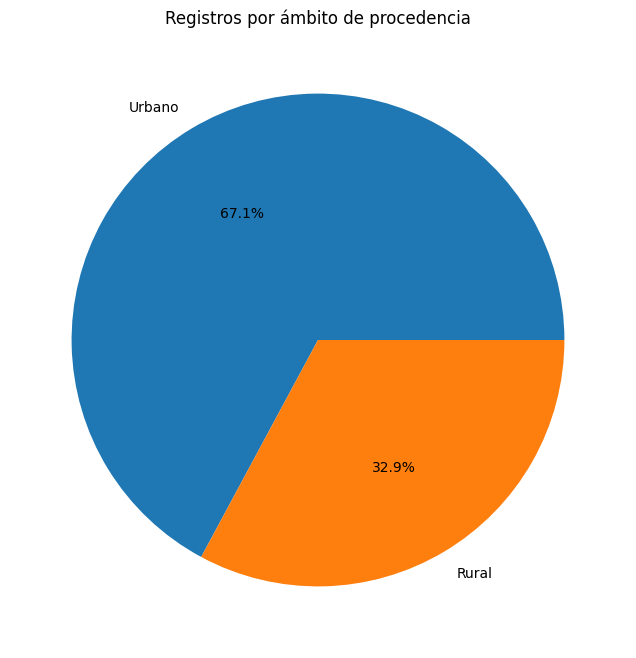

In [22]:
# Contar registros por ámbito
counts = df["ambito_procedencia"].value_counts()

# Gráfica redonda
plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title("Registros por ámbito de procedencia")

plt.show()

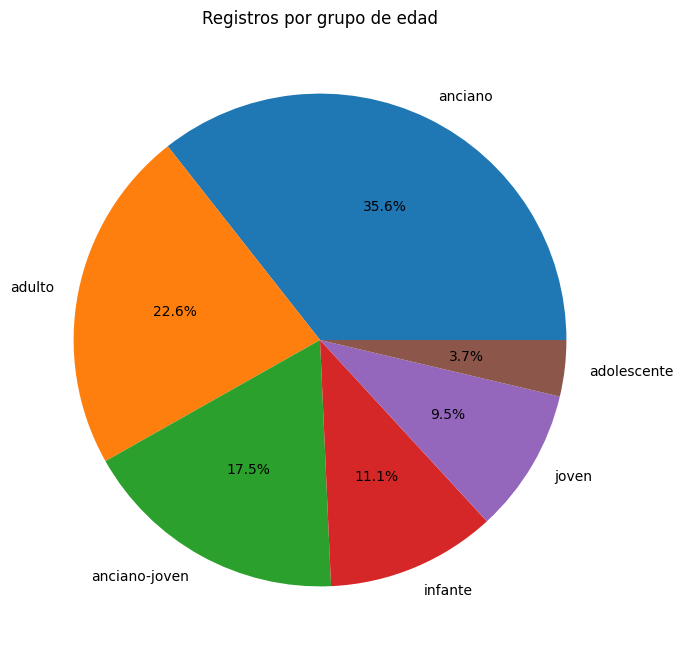

In [23]:
# Contar registros grupo de edad
counts = df["grupo_edad"].value_counts()

# Gráfica redonda
plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title("Registros por grupo de edad")

plt.show()

In [24]:
# pasamos nivel_triaje a numérico
df["nivel_triaje"] = df["nivel_triaje"].replace("Desconocido", 0)
df["nivel_triaje"] = pd.to_numeric(df["nivel_triaje"])

In [25]:
#vemos el balance del campo
df["sexo"].value_counts()

,count
sexo,
Mujer,417711
Hombre,365061


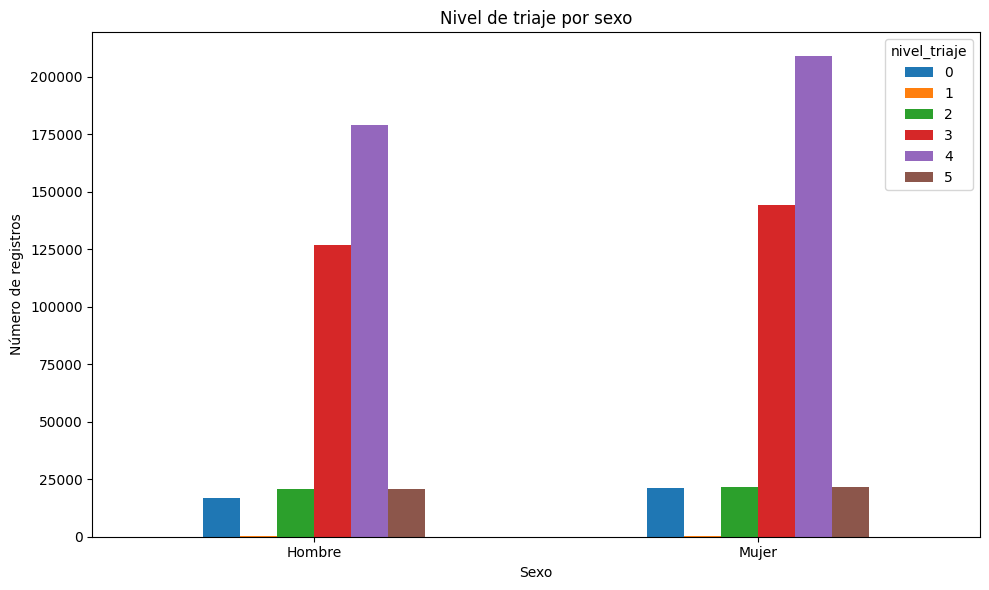

In [26]:
# Contar registros por sexo y nivel_triaje
grouped = (
    df.groupby(["sexo", "nivel_triaje"])
      .size()
      .unstack(fill_value=0)
)

# Plot de barras
grouped.plot(kind="bar", figsize=(10,6))

plt.xlabel("Sexo")
plt.ylabel("Número de registros")
plt.title("Nivel de triaje por sexo")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

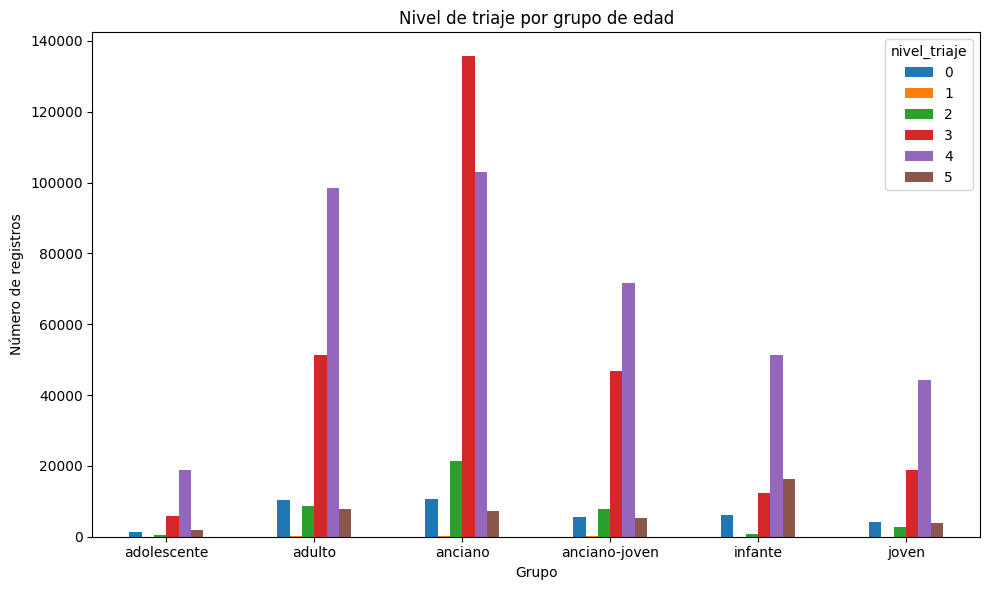

In [27]:
# Contar registros por sexo y nivel_triaje
grouped = (
    df.groupby(["grupo_edad", "nivel_triaje"])
      .size()
      .unstack(fill_value=0)
)

# Plot de barras
grouped.plot(kind="bar", figsize=(10,6))

plt.xlabel("Grupo")
plt.ylabel("Número de registros")
plt.title("Nivel de triaje por grupo de edad")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

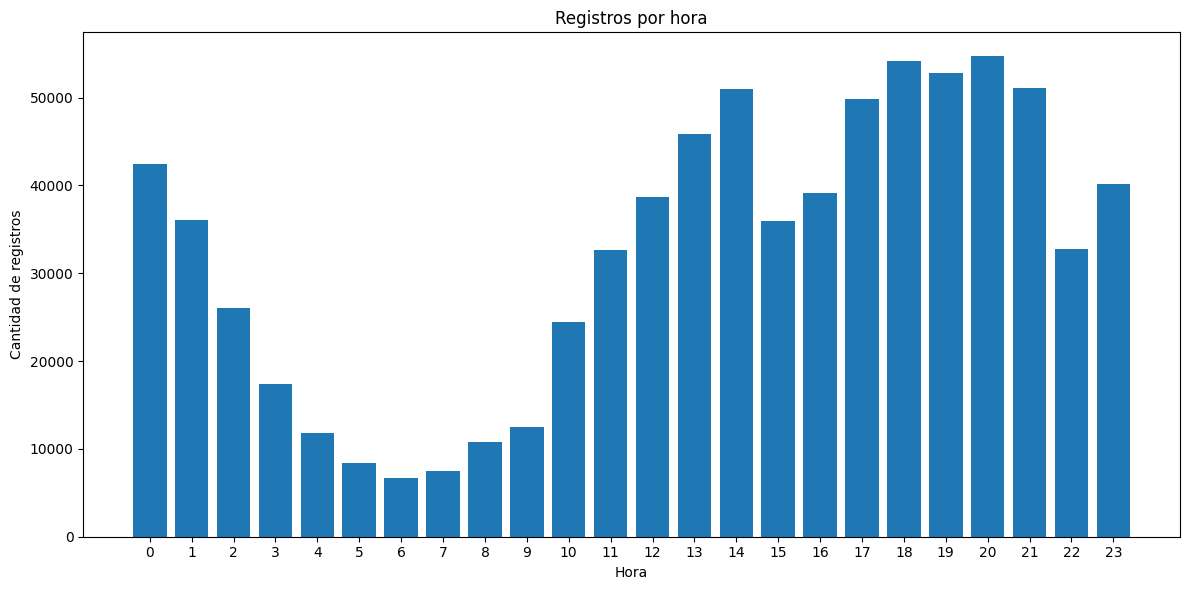

In [28]:
counts = (
    df["hora_redondeada"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.bar(
    counts.index,
    counts.values
)

plt.xlabel("Hora")
plt.ylabel("Cantidad de registros")
plt.title("Registros por hora")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

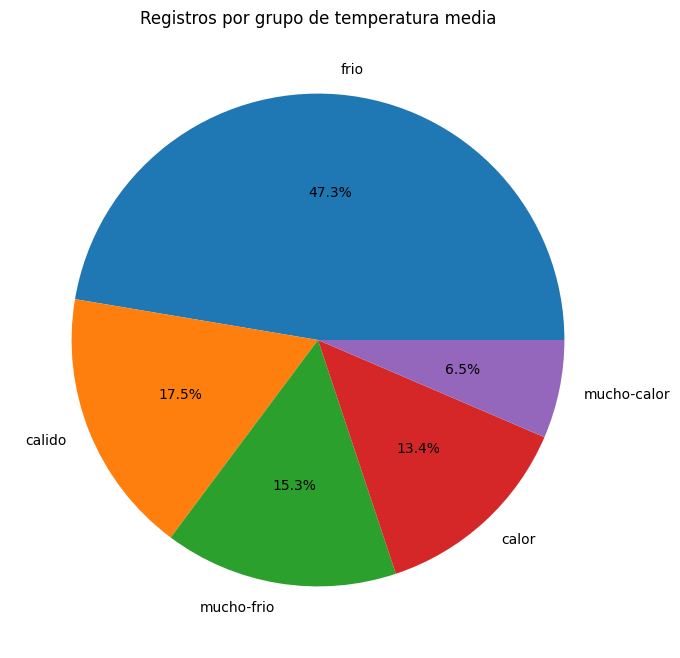

In [29]:
# Contar registros grupo de edad
counts = df["grupo_temperatura_media"].value_counts()

# Gráfica redonda
plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title("Registros por grupo de temperatura media")

plt.show()

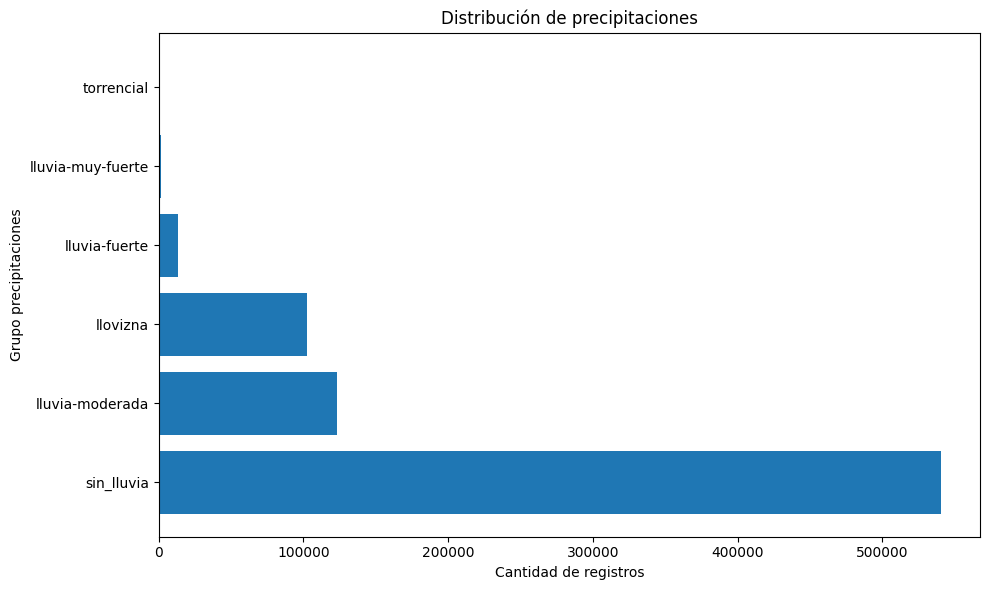

In [30]:
counts = df["grupo_precipitaciones"].value_counts()


plt.figure(figsize=(10,6))

plt.barh(
    counts.index,
    counts.values
)

plt.xlabel("Cantidad de registros")
plt.ylabel("Grupo precipitaciones")
plt.title("Distribución de precipitaciones")

plt.tight_layout()
plt.show()

In [32]:
df.to_csv("df_final_mejora_1.csv", index=False)

In [ ]:
df = df.drop(['hora', "nivel_triaje", "edad", "sexo", "grupo_edad", "fecha_hora", "hora_redondeada"], axis=1)

In [ ]:
# Asegurar datetime
df["fecha"] = pd.to_datetime(df["fecha"])

# Agrupar por fecha, hospital y provincia
df_diario = (
    df.groupby(["fecha", "hospital", "provincia", "dia_semana", "mes", "year"])
    .size()
    .reset_index(name="target_pacientes")
    .sort_values(["provincia", "hospital", "fecha", "dia_semana", "mes", "year"])
)

df_diario

In [ ]:
df_diario["pacientes_ayer"] = (
    df_diario
    .groupby(["hospital", "provincia"])["target_pacientes"]
    .shift(1)
)

In [ ]:
df_diario["pacientes_ayer"] = df_diario["pacientes_ayer"].fillna(
    df_diario["target_pacientes"]
).astype(int)

In [ ]:
df = df.drop(['dia_semana', "ambito_procedencia", "hospital", "dia", "pacientes_ayer", "target_pacientes", "grupo_temperatura_media", "grupo_precipitaciones", "mes_nombre", "mes", "year"], axis=1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df_final = df_diario.merge(
    df,
    on=["provincia", "fecha"],
    how="left"
)

In [ ]:
columna_auxiliar = df_final.pop("target_pacientes")
df_final["target_pacientes"] = columna_auxiliar

In [ ]:
df_final

In [ ]:
df_final.to_csv("df_final.csv", index=False)